# 합성곱 신경망을 사용한 이미지 분류

In [ ]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
import keras
import tensorflow as tf

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

## 패션 MNIST 데이터 불러오기

In [ ]:
import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

print("훈련 이미지:", train_input.shape)
print("훈련 정답:", train_target.shape)
print("테스트 이미지:", test_input.shape)

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0  # (60000, 28, 28) -> (60000, 28, 28, 1)  28 x 28 x 1 --> 흑백 이미지이므로 채널 '1'

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)


훈련 이미지: (60000, 28, 28)
훈련 정답: (60000,)
테스트 이미지: (10000, 28, 28)


## 합성곱 신경망 만들기

### model을 만들고 Conv2D 합성곱 층 add --> 32개 필터 ,  커널 (3x3) , relu함수, same padding

* 28 x 28 x 1

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu',
                              padding='same'))

### 최대 폴링 (2x2) --> 가로 x 세로의 크기가 같으면 정수1개로 지정 가능

* 14 x 14 x 32

In [ ]:
model.add(keras.layers.MaxPooling2D(2))

### Conv2D --> 64 필터 , 커널 (3 x 3) ,relu 함수, samw padding  --> 14 x 14 X 64

### 최대 폴링 --> 7 x 7 x 64

In [ ]:
model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu',
                              padding='same'))
model.add(keras.layers.MaxPooling2D(2))

### 확률을 계산하기 위해 1차원 --> 뉴런 100 --> 40% 은닝층 사용 안함(dropout) --> 10개 class 다중 분류

In [ ]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

### model.summary() 출력 결과

* conv2d ----> 3 x 3 x 1 x 32 + 32 = 320
* conv2d_1 --> 3 x 3 x 1 x 32 x 64 + 64 = 18,496
* dense -----> 3136 x 100 + 100 = 313,700
* dense_1 ---> 100 x 10 + 10 = 1,010

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
keras.utils.plot_model(model)

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

## 모델 컴파일과 훈련

### 옵티마이져 adam 사용

### ModelCheckpoint --> = 가장 잘한 모델을 저장 , 'best-cnn-model.keras'

### EarlyStopping  --> 검증 성능이 좋아지지 않는 상태가 2번 계속되면 멈추어라 , patience=2


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              # 현재 텐서플로 버전에서는 최대 풀링에 대한 결정적인 XLA 구현이 없기 때문에
              # enable_op_determinism() 호출로 인해 오류가 발생합니다.
              # 이를 피하기 위해 jit_compile 옵션을 False로 지정합니다.
              # https://github.com/tensorflow/tensorflow/issues/69417
              jit_compile=False)
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8105 - loss: 0.5285 - val_accuracy: 0.8797 - val_loss: 0.3276
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8756 - loss: 0.3481 - val_accuracy: 0.8993 - val_loss: 0.2746
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8919 - loss: 0.2977 - val_accuracy: 0.9018 - val_loss: 0.2552
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9043 - loss: 0.2651 - val_accuracy: 0.9093 - val_loss: 0.2459
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9124 - loss: 0.2419 - val_accuracy: 0.9132 - val_loss: 0.2340
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9187 - loss: 0.2213 - val_accuracy: 0.9160 - val_loss: 0.2284
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9242 - loss: 0.2038 - val_accuracy: 0.9191 - val_loss: 0.2255
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9306 - loss: 0.

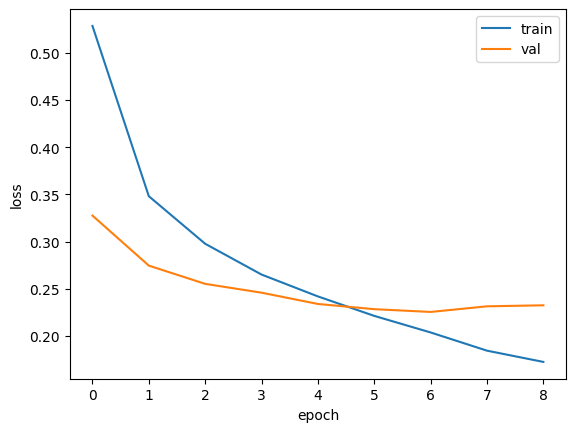

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9191 - loss: 0.2255


[0.225491002202034, 0.9190833568572998]

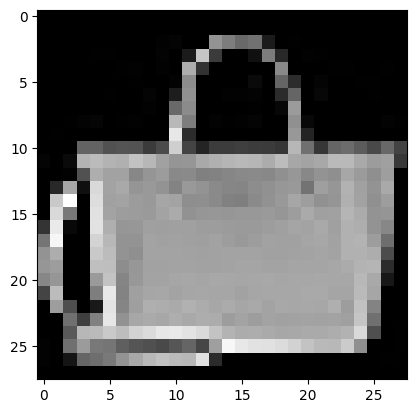

In [ ]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray')
plt.show()

### CNN 모델은 한장의 이미지라도 (1,28,28,1) 형태로 처리됩니다  --> (26,28,1) 아닙니다

```
(1, 28, 28, 1)
 ↑   ↑   ↑   ↑
 │   │   │   └─ 채널 수 : 흑백이므로 1
 │   │   └───── 이미지 너비 : 28
 │   └───────── 이미지 높이 : 28
 └───────────── 배치 크기 : 이미지 1장
```

In [ ]:
preds = model.predict(val_scaled[0:1])

# 10개의 확률입니다
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
[[2.2989703e-17 2.2168874e-23 1.9206553e-18 2.3270205e-16 1.6824198e-15
  4.0414136e-16 1.9692811e-17 2.6914546e-15 1.0000000e+00 1.2395960e-17]]


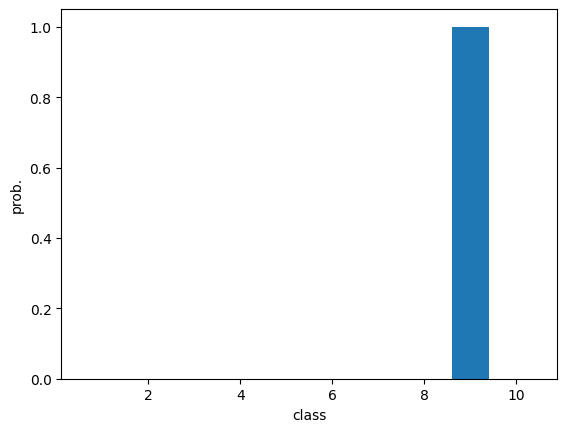

In [ ]:
plt.bar(range(1, 11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

In [ ]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
           '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

### 가장 높은 확율의 클래스 이름은?

In [ ]:
import numpy as np

print(classes[np.argmax(preds)])

가방


### 훈련 데이터와 동일하게 테스트 이미지도 정규화합니다.

In [ ]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

### 최종 모델의 성능 확인

In [ ]:
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9160 - loss: 0.2488


[0.2488059252500534, 0.9160000085830688]